# PR19 · A streamline is a model trajectory, not an axon

<!-- paper-first -->
### Research question

**Reading:** [PP06](../../curriculum/papers/processing.md#pp06). Review the assigned figure or result before starting the lesson.

**Question:** How can a plausible-looking streamline connect the wrong endpoints?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Show how crossing populations violate a single tensor.
- Separate local orientation estimates from global paths.
- Explain seed, stopping and modeling effects on tractography counts.

## Understand the operation

Within a diffusion voxel, multiple fiber populations can contribute to one measured signal. A mixture of two tensor signals is not generally equal to the signal of their average tensor, because the exponential signal model is nonlinear. A fitted single tensor can therefore blur distinct directions into one ellipsoid and show lower FA even when both underlying populations are strongly anisotropic.

More flexible reconstructions estimate orientation distributions under additional acquisition and model assumptions. Those distributions are not direct photographs of axons. Tractography takes local direction information and numerical rules to propagate paths from seeds. Step size, curvature limits, stopping criteria, masks and direction uncertainty affect the resulting streamlines. Deterministic and probabilistic methods express these choices differently; neither guarantees a complete or uniquely correct wiring diagram.

Local ambiguity is a global problem: at a crossing, several continuations can be compatible with a local measurement. A trajectory can terminate early or connect incorrect regions. Increasing seeds increases numerical trajectories without adding axons. Streamline counts and connection weights need a justified interpretation and normalization; they should not be called literal fiber counts. Endpoint assignment also depends on registration and parcellation boundaries.

The lab compares a two-population synthetic signal with a best-fitting single-tensor model and then draws two simple candidate paths from the same seed. The path calculation is deliberately small and does not use a diffusion reconstruction to choose directions; it isolates how a propagation choice changes the result. Complete DIPY/FSL tracking practicals provide the real-tool step, while this exercise supplies checks that help you question their outputs.

## Transformation contract

**Input:** diffusion measurements or local direction candidates, seeds and tracking rules. **Output:** fitted orientation model and streamlines. **Lost by one tensor:** distinct crossing components. **Added by tracking:** assumptions about continuation; these are not newly measured connections.


## Read the actual course material

- [DIPY: simulate multiple tensors](https://github.com/dipy/dipy/blob/05df74a36c48e38ef1aa7420440abb9f1d14e6d4/doc/examples/simulate_multi_tensor.py). BSD-3-Clause project; linked source.
- [DIPY: introduction to streamline tracking](https://github.com/dipy/dipy/blob/05df74a36c48e38ef1aa7420440abb9f1d14e6d4/doc/examples/tracking_introduction_eudx.py). BSD-3-Clause project; linked source.
- [Oxford FSL: FDT pipeline, TOPUP, EDDY, DTIFIT and TBSS](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/fdt1/index.html). Public university practical; educational data terms at source; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Compare the crossing mixture with a single-tensor fit and the averaged tensor. Explain the lowered fitted FA without claiming tissue damage. Then change only a tracking direction or step limit and describe what has changed in the resulting trajectory. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(1919); g=rng.normal(size=(120,3)); g/=np.linalg.norm(g,axis=1)[:,None]
D1=np.diag([.0017,.0003,.0003]); D2=np.diag([.0003,.0017,.0003]); b=1000.
atten=lambda D: np.exp(-b*np.einsum('ni,ij,nj->n',g,D,g))
signal=.5*atten(D1)+.5*atten(D2)
x,y,z=g.T; X=np.column_stack([x*x,y*y,z*z,2*x*y,2*x*z,2*y*z])
a=np.linalg.lstsq(X,-np.log(signal)/b,rcond=None)[0]
Dfit=np.array([[a[0],a[3],a[4]],[a[3],a[1],a[5]],[a[4],a[5],a[2]]])
single=atten(Dfit); mse=np.mean((single-signal)**2)
FA=lambda D: np.sqrt(1.5*np.sum((np.linalg.eigvalsh(D)-np.trace(D)/3)**2)/np.sum(D*D))
print('single-tensor mismatch MSE:',mse,'population/fit FA:',FA(D1),FA(Dfit))
assert mse>1e-4 and FA(Dfit)<FA(D1)
assert not np.allclose(signal,atten((D1+D2)/2))


single-tensor mismatch MSE: 0.0004648029102399988 population/fit FA: 0.7990222037494894 0.44435833469834557


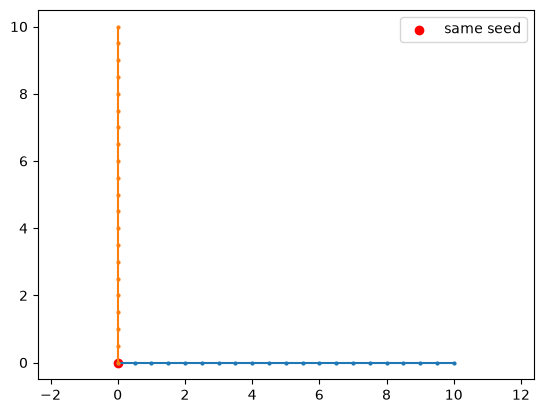

Two selected continuations; duplicating seeds would duplicate paths, not axons.


In [2]:
def track(seed,direction,step=.5,nsteps=20):
    direction=np.asarray(direction,dtype=float); direction/=np.linalg.norm(direction)
    points=[np.asarray(seed,dtype=float)]
    for _ in range(nsteps): points.append(points[-1]+step*direction)
    return np.array(points)
paths=[track([0,0],[1,0]),track([0,0],[0,1])]
for p in paths: plt.plot(p[:,0],p[:,1],'o-',markersize=2)
plt.scatter([0],[0],color='red',label='same seed'); plt.axis('equal'); plt.legend(); plt.show()
assert len(paths)==2 and not np.array_equal(paths[0][-1],paths[1][-1])
print('Two selected continuations; duplicating seeds would duplicate paths, not axons.')


## Check and explain

The single-tensor residual is nonzero despite noise-free measurements. The fitted FA is lower than each anisotropic component’s FA. Two selected directions from one seed reach different endpoints; the simple propagation rule alone cannot choose which is anatomically true.

## Deliberately wrong method

Interpreting lower FA as proof of damaged fibers ignores crossing geometry. Calling two generated trajectories two axons confuses algorithm output with microscopic counts. A visually plausible tract does not establish sensitivity, specificity or causal direction.

## Transfer to an actual dataset or tool — guided assignment

Work through DIPY’s pinned tracking introduction and compare the direction model, seed mask and stopping criterion with the FSL diffusion course’s advanced tractography material. Use separately obtained data and record every choice. Repeat one parameter at a time, overlay endpoints on anatomy, and state what changed in the connection measure. Add a warning in your results about false-positive/negative paths and the absence of directed neural signaling information.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why is a signal mixture not the average-tensor signal? **Answer:** averaging and the exponential mapping do not commute.
2. What does increasing seed count measure? **Answer:** more algorithmic sampling under the chosen model, not a known increase in anatomical fibers.


### Return to the research question

Revisit [PP06](../../curriculum/papers/processing.md#pp06) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
